# FlexBE: verification model, an error in Algorithm 1, and how to make it programmable

**Companion notebook to** X. Liu, R. Wu, P. H. W. Leong, *"A Flexible FPGA-based
Butterfly Engine for Accelerating Signal Processing and Machine Learning"*.

This notebook contains the complete analysis: a cycle-level simulator of the
FlexBE engine and the BSPNet application, the diagnosis and repair of the index
generator in Algorithm 1, a RISC-V vector extension proposal, a quantitative
comparison of four ways to make the workload software programmable, and a model
of how the result attaches to a Zynq UltraScale+ MPSoC.

## What is established here

| # | Result | Where |
|---|---|---|
| 1 | A cycle-level model reproduces the paper's headline numbers exactly: 15,360 cycles for four 32,768-point FFTs, 0.214 ms for cfg-6 at 300 MHz | Part I |
| 2 | **Algorithm 1 lines 5–6 do not produce a conflict-free schedule.** Proven by exhaustive enumeration on small cases. A repair is derived, proved and verified; lines 7–11 are untouched | Part II |
| 3 | `vrgather` *is* the FCS. A RISC-V vector extension family follows from the paper's own Θ(P²) vs Θ(mP) argument | Part III |
| 4 | A custom **vector extension costs 4.45× against the hardwired datapath**; a **microcoded/RoCC sequencer costs 1.00–1.06×**. The vector options are operand-bandwidth bound, and fixing that rebuilds the accelerator | Part IV |
| 5 | On Zynq the PYNQ flow is **host bound (+281%)**, not accelerator bound; a descriptor ring reaches 92% of datapath peak. One HP port suffices | Part V |

## Method

Nothing below is asserted where it could be measured. The simulator executes the
real dataflow — banked memory, switching network, butterfly units, per-cycle
control — and the instruction-level models *generate and functionally execute*
their instruction traces before any cycle is counted. Assumptions are confined
to named dataclasses (`MachineConfig`, `PSPLConfig`) and listed in Part VI.

---
## 0. Setup

The five modules and what each owns:

| module | contents |
|---|---|
| `flexbe.py` | the engine: shift-down memory, PRS/FCS, schedule, bit reversal, arithmetic, Eq. (10) |
| `bspnet.py` | the application: Eq. (1) features, BL branches, Table 7 configs, latency model |
| `isa_model.py` | instruction-level backend: microcoded / RoCC / RVV options |
| `zynq_model.py` | PS–PL attachment: descriptor ring, DMA overlap, completion |
| `test_flexbe.py` | 59 tests covering all of the above |

In [1]:
import math, sys, subprocess
import numpy as np
import matplotlib.pyplot as plt

import flexbe as fx
import bspnet as bs
import isa_model as im
import zynq_model as zm

plt.rcParams.update({"figure.figsize": (7.2, 3.6), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
print("numpy", np.__version__, "| python", sys.version.split()[0])
print("modules loaded:", ", ".join(m.__name__ for m in (fx, bs, im, zm)))

numpy 2.4.6 | python 3.13.13
modules loaded: flexbe, bspnet, isa_model, zynq_model


---
# Part I — The architecture and its simulator

## 1.1 The shift-down storage scheme, Eq. (3)

The engine holds in-flight data in $P = 2P_{bu}$ single-port RAM banks. Element
index $I$ lives in bank $a_y$ at depth $a_x$:

$$a_x = I \gg m, \qquad a_y = \mathrm{bsm}(I) = \big[(\mathrm{popcount}(I \gg m) + (I \bmod 2^m))\big] \bmod 2^m$$

with $m = \log_2(2P_{bu})$. Read this as: **a RAM row is $2^m$ consecutive
indices, and row $H$ is cyclically rotated by $\mathrm{popcount}(H)$ banks.**
That single sentence is what makes the whole schedule derivation work, and it is
worth stating in the paper more explicitly than Eq. (3) does.

Two immediate consequences:

* every element owns a unique (bank, depth) slot — the map is a bijection;
* the $2^m$ elements of one row occupy **all** $2^m$ banks exactly once.

In [2]:
m = 3                     # P_bu = 4 -> 8 banks
n = 6                     # N = 64
N, P = 1 << n, 1 << m
idx = np.arange(N)
bank, depth = fx.bsm_array(idx, m), idx >> m

print("bijection check:", len(np.unique(bank * (N // P) + depth)) == N)
print("\nbank occupancy of the first four rows (row H, banks of its 8 elements):")
for H in range(4):
    row = idx[(idx >> m) == H]
    print(f"  H={H}  popcount={fx.popcount(H)}  banks={fx.bsm_array(row, m).tolist()}")

bijection check: True

bank occupancy of the first four rows (row H, banks of its 8 elements):
  H=0  popcount=0  banks=[0, 1, 2, 3, 4, 5, 6, 7]
  H=1  popcount=1  banks=[1, 2, 3, 4, 5, 6, 7, 0]
  H=2  popcount=1  banks=[1, 2, 3, 4, 5, 6, 7, 0]
  H=3  popcount=2  banks=[2, 3, 4, 5, 6, 7, 0, 1]


## 1.2 Deriving the conflict-free schedule

Stage $k$ pairs indices differing in bit $h$. The paper's control law
(Algorithm 1 lines 8–11) is $S^i = n-k-1$ on $(n-m) \le k \le (n-2)$ and $0$
elsewhere — which is only correct if

$$h = n - 1 - k$$

i.e. **decimation in frequency**: natural-order input, bit-reversed output,
which is exactly why the Sec. 3.3 write-back path exists. Given that, conflict
freedom forces two regimes:

**Case A, $h < m$** — both operands share a RAM row. Read the *whole* row: banks
$(\mathrm{popcount}(H) + \mathit{low}) \bmod 2^m$ for $\mathit{low} = 0 \ldots 2^m-1$ are all
distinct. Slot $j$ holds $\mathit{low} = \pi_h[j]$, so slot $j$ reads bank
$(\pi_h[j] + \mathrm{popcount}(H)) \bmod 2^m$ — a fixed stride permutation then a
rotation, giving $\mathbf{P}_f = \mathbf{P}_s \times \mathbf{P}_r$ with $S = h$,
$R = \mathrm{popcount}(H)$.

**Case B, $h \ge m$** — the partner is in row $H + 2^{h-m}$. Choose $H$ with bit
$h-m$ clear, so $\mathrm{popcount}(H + 2^{h-m}) = \mathrm{popcount}(H)+1$. Take the
$P_{bu}$ even (or odd) low values from both rows: slot $j$ reads bank
$(\mathrm{popcount}(H) + e + j) \bmod 2^m$ — a pure rotation, $S = 0$.

Each regime emits exactly $N/2^m = N/(2P_{bu})$ cycles per stage and visits every
index once. **The subset-switch state falls out as $S = h$ when $h < m$, else 0 —
identical to the published line 9.**

In [3]:
sched = fx.ButterflySchedule(n=10, m=5, validate=True)   # N=1024, P_bu=16
print(f"N={sched.N}, 2*P_bu={sched.P}, stages={sched.n_stages}, "
      f"cycles/stage={sched.cycles_per_stage}, total={sched.total_cycles}")
print("validate() passed: conflict-free, complete coverage, PRS == FCS, R = bsm(I[0])\n")
print(f"{'k':>2} {'hole h':>7} {'S (ours)':>9} {'S (Alg.1 line 9)':>17} {'regime':>8} {'R of first 4 cycles':>22}")
for k, stage in enumerate(sched.stages):
    c = stage[0]
    reg = "row" if c.hole < sched.m else "2-row"
    print(f"{k:>2} {c.hole:>7} {c.S:>9} {sched.paper_subset_state(k):>17} {reg:>8} "
          f"{', '.join(str(x.R) for x in stage[:4]):>22}")

N=1024, 2*P_bu=32, stages=10, cycles/stage=32, total=320
validate() passed: conflict-free, complete coverage, PRS == FCS, R = bsm(I[0])

 k  hole h  S (ours)  S (Alg.1 line 9)   regime    R of first 4 cycles
 0       9         0                 0    2-row             0, 1, 1, 2
 1       8         0                 0    2-row             0, 1, 1, 2
 2       7         0                 0    2-row             0, 1, 1, 2
 3       6         0                 0    2-row             0, 1, 1, 2
 4       5         0                 0    2-row             0, 1, 1, 2
 5       4         4                 4      row             0, 1, 1, 2
 6       3         3                 3      row             0, 1, 1, 2
 7       2         2                 2      row             0, 1, 1, 2
 8       1         1                 1      row             0, 1, 1, 2
 9       0         0                 0      row             0, 1, 1, 2


### The invariants, checked rather than assumed

`ButterflySchedule.validate()` asserts, for every cycle of every stage: distinct
banks, no element visited twice, complete coverage, correct pairing on the hole
bit, $\mathbf{P}_f = \mathbf{P}_s\times\mathbf{P}_r$, and $R^i = \mathrm{bsm}(I^i[0])$.
Below it runs across a range of sizes.

In [4]:
print(f"{'N':>7} {'P_bu':>5} {'stages':>7} {'cycles':>8}  validated")
for nn, P_bu in [(3,1),(4,2),(6,4),(8,4),(10,16),(12,16),(5,16)]:
    mm = (2*P_bu).bit_length()-1
    if nn < mm: continue
    s = fx.ButterflySchedule(nn, mm, validate=True)
    print(f"{s.N:>7} {P_bu:>5} {s.n_stages:>7} {s.total_cycles:>8}  ok")

      N  P_bu  stages   cycles  validated
      8     1       3       12  ok
     16     2       4       16  ok
     64     4       6       48  ok
    256     4       8      256  ok
   1024    16      10      320  ok
   4096    16      12     1536  ok
     32    16       5        5  ok


## 1.3 PRS versus FCS — the paper's central cost argument

The FCS is a general $2P_{bu}$-to-$2P_{bu}$ crossbar: each of $2P_{bu}$ output
ports is a $2P_{bu}$-to-1 mux, i.e. $2P_{bu}-1$ 2:1 muxes each (Eq. 4), so
$C_{\mathrm{fcs}} = \Theta(P_{bu}^2)$. The PRS is a barrel shifter plus one of
only $m$ stride permutations: $mP + (m{+}1)2^{m-1}$ 2:1 muxes, i.e.
$C_{\mathrm{prs}} = \Theta(mP_{bu})$.

**Hand calculation at 128 ports** ($P_{bu} = 64$, $m = 7$):

$$C_{\mathrm{fcs}} = 128 \times 127 = 16{,}256 \qquad C_{\mathrm{prs}} = 7(128) + 8(64) = 1{,}408 \qquad \text{ratio } 11.5\times$$

Note the crossover: at 4 ports the staged PRS is actually *worse* (14 vs 12
muxes). Fig. 9 starts at 4 ports, where the two curves nearly touch — consistent.

 ports  m   FCS mux2   PRS mux2   ratio   FCS regs   PRS regs
     4  2         12         14   0.86x        192        128
     8  3         56         40   1.40x        896        384
    16  4        240        104   2.31x      3,840      1,024
    32  5        992        256   3.88x     15,872      2,560
    64  6      4,032        608   6.63x     64,512      6,144
   128  7     16,256      1,408  11.55x    260,096     14,336


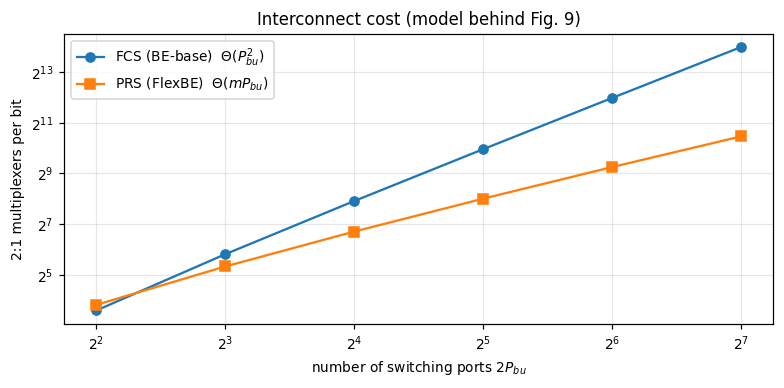

In [5]:
ports, fcs, prs = [], [], []
print(f"{'ports':>6} {'m':>2} {'FCS mux2':>10} {'PRS mux2':>10} {'ratio':>7} {'FCS regs':>10} {'PRS regs':>10}")
for P_bu in (2,4,8,16,32,64):
    c = fx.interconnect_cost(P_bu)
    ports.append(c['ports']); fcs.append(c['fcs_mux2']); prs.append(c['prs_mux2'])
    print(f"{c['ports']:>6} {c['m']:>2} {c['fcs_mux2']:>10,} {c['prs_mux2']:>10,} "
          f"{c['ratio']:>6.2f}x {c['fcs_pipeline_regs']:>10,} {c['prs_pipeline_regs']:>10,}")

fig, ax = plt.subplots()
ax.plot(ports, fcs, 'o-', label='FCS (BE-base)  $\\Theta(P_{bu}^2)$')
ax.plot(ports, prs, 's-', label='PRS (FlexBE)  $\\Theta(m P_{bu})$')
ax.set_xscale('log', base=2); ax.set_yscale('log', base=2)
ax.set_xlabel('number of switching ports $2P_{bu}$'); ax.set_ylabel('2:1 multiplexers per bit')
ax.set_title('Interconnect cost (model behind Fig. 9)'); ax.legend()
plt.tight_layout(); plt.show()

## 1.4 One datapath, two workloads: FFT twiddles and BL weights

A butterfly unit applies a general $2\times2$ coefficient matrix. The FFT is the
special case $\begin{pmatrix}1 & 1\\ W & -W\end{pmatrix}$; a butterfly-linear
layer uses trained weights, which is exactly the `[2,2,l/2,log2 l]` shape of
Table 4. The DIF twiddle for hole bit $h$ and lower index $a$ is
$W_l^{(a \bmod 2^h)\cdot l/2^{h+1}}$.

Below: the same engine computes an exact FFT, and an exact BL layer, and the BL
layer is shown to equal its dense matrix.

In [6]:
eng = fx.FlexBE(P_bu=16)
rng = np.random.default_rng(0)

x = rng.normal(size=(4, 1024)) + 1j*rng.normal(size=(4, 1024))
y, st = eng.transform(x, bitrev=True, datapath='cycle')
print("FFT :", st)
print("      max relative error vs numpy.fft =",
      f"{np.max(np.abs(y-np.fft.fft(x,axis=1)))/np.max(np.abs(np.fft.fft(x,axis=1))):.2e}")

W = fx.random_bl_coefficients(32, rng)
M = np.asarray(eng.transform(np.eye(32), W, datapath='cycle')[0]).T
z = rng.normal(size=(7, 32))
yb, _ = eng.transform(z, W, datapath='cycle')
print("\nBL  : engine output equals the dense butterfly matrix:",
      np.allclose(yb, z @ M.T))

FFT : N=1024 l=1024 P_sub=1 P_N=4 stages=10 bfly_cycles=1280 bitrev_cycles=128 total=1408
      max relative error vs numpy.fft = 4.58e-16

BL  : engine output equals the dense butterfly matrix: True


## 1.5 Sub-parallelism — Algorithm 2 and Eq. (5)

BE-base cannot process $l < 2P_{bu}$: short vectors must be zero padded, wasting
the datapath. FlexBE instead interleaves $P_{sub} = 2P_{bu}/l$ transforms into
one computational vector (Eq. 5) and stops after $\log_2 l$ stages.

This matters because it is where BSPNet actually spends its time: cfg-6 uses
$d_{in}=8$ against $2P_{bu}=32$, so $P_{sub}=4$.

**Hand calculation** — 1024 vectors of length 8 on one $P_{bu}=16$ engine:
padding to 32 costs $1024 \times 32/(2\cdot16) \times \log_2 32 = 5{,}120$ cycles;
sub-parallelism costs $1024/4 \times \log_2 8 = 768$. Ratio $6.67\times$, and it
decomposes as $P_{sub}=4$ times the wasted stages $5/3$.

In [7]:
print(f"{'l':>4} {'N':>5} {'P_sub':>6} {'stages':>7} {'cycles/1024 vec':>16} {'vs zero-pad':>12}")
for l in (2,4,8,16,32,64):
    N_, ps = eng.geometry(l)
    flex = fx.layer_cycles(1024, l, P_be=1, P_bu=16)
    pad  = fx.layer_cycles(1024, max(l,32), P_be=1, P_bu=16)
    print(f"{l:>4} {N_:>5} {ps:>6} {int(math.log2(l)):>7} {flex:>16,.0f} {pad/flex:>11.2f}x")

xs = rng.normal(size=(8,8)) + 1j*rng.normal(size=(8,8))
ys, sts = eng.transform(xs, bitrev=True, datapath='cycle')
print(f"\neight 8-point FFTs on one engine: P_sub={sts.P_sub}, "
      f"{sts.butterfly_cycles} butterfly cycles, matches numpy: "
      f"{np.allclose(ys, np.fft.fft(xs,axis=1))}")

   l     N  P_sub  stages  cycles/1024 vec  vs zero-pad
   2    32     16       1               64       80.00x
   4    32      8       2              256       20.00x
   8    32      4       3              768        6.67x
  16    32      2       4            2,048        2.50x
  32    32      1       5            5,120        1.00x
  64    64      1       6           12,288        1.00x

eight 8-point FFTs on one engine: P_sub=4, 6 butterfly cycles, matches numpy: True


## 1.6 Bit reversal — Algorithm 3, Eqs. (6)–(9)

DIF leaves the output bit-reversed, so the write-back to the global buffer must
apply $y_k = d_j$ with $j = \mathrm{bit\text{-}rev}_n(k)$ while staying conflict free on
*both* memories and hitting the bandwidth bound of $N/P$ cycles.

Algorithm 3 slices the index as $j = [H\,(m)\,|\,Q\,(q)\,|\,R\,(r)\,|\,M\,(m)]$ and constructs
$x = (a - \mathrm{popcount}(\mathit{high})) \bmod P$ so that lane $a$ always reads bank $a$;
the destination bank is $\mathrm{bit\text{-}rev}_m((a+u) \bmod P)$ (Eq. 7) — a fixed bit
reversal followed by a barrel rotation. **This part of the paper is correct as
printed**, and the checks below confirm every claim.

In [8]:
print(f"{'N':>7} {'P':>4} {'cycles':>8} {'N/P':>8}  read-CF  write-CF  lane a reads bank a  permutation")
for N_, P_bu in [(1024,16),(32768,16),(4096,4),(256,4)]:
    nn, mm = int(math.log2(N_)), (2*P_bu).bit_length()-1
    j, k = fx.bitrev_schedule(nn, mm)
    Pp = 1 << mm
    read_cf  = all(len(np.unique(fx.bsm_array(jv, mm))) == Pp for jv in j)
    write_cf = all(len(np.unique(kv & (Pp-1)))          == Pp for kv in k)
    lane     = all(np.array_equal(fx.bsm_array(jv, mm), np.arange(Pp)) for jv in j)
    perm     = len(np.unique(j)) == N_ and np.array_equal(k, fx.bit_rev_array(nn)[j])
    print(f"{N_:>7} {Pp:>4} {j.shape[0]:>8} {N_//Pp:>8}  {str(read_cf):>7}  {str(write_cf):>8}"
          f"  {str(lane):>19}  {perm}")

      N    P   cycles      N/P  read-CF  write-CF  lane a reads bank a  permutation
   1024   32       32       32     True      True                 True  True
  32768   32     1024     1024     True      True                 True  True
   4096    8      512      512     True      True                 True  True
    256    8       32       32     True      True                 True  True


## 1.7 The cycle model, Eq. (10), and the abstract's headline

$$\text{cycles} \approx \frac{P_N N}{2 P_{sub} P_{be} P_{bu}} \times \log_2\frac{N}{P_{sub}}$$

**Hand calculation for the abstract's claim** — four 32,768-point FFTs on
$P_{be}=4$, $P_{bu}=16$:

$$\frac{4 \times 32768}{2 \times 1 \times 4 \times 16} \times \log_2 32768 = 1024 \times 15 = 15{,}360 \text{ cycles} = 51.2\,\mu s \text{ at } 300\,\text{MHz}$$

Note on interpretation: $P_N$ must be read as the number of *length-$l$ input*
sequences and $N$ as the engine computational length $\max(l, 2P_{bu})$; with
that reading Eq. (10) is consistent for all $P_{sub}$. Worth a clarifying
sentence in the paper.

The cell below both evaluates the formula and *measures* the simulated engine.

In [9]:
print("Eq. (10) :", f"{fx.cycles_eq10(4, 32768, 1, P_be=4, P_bu=16):,.0f} cycles  (paper: 15,360)")

arr = fx.BEArray(P_be=4, P_bu=16)
xb = rng.normal(size=(4,32768)) + 1j*rng.normal(size=(4,32768))
yb, stb = arr.transform(xb, bitrev=True, datapath='cycle')
print("measured :", f"{stb.butterfly_cycles:,} butterfly + {stb.bitrev_cycles:,} bit-reversal cycles")
print("           max abs error vs numpy.fft =", f"{np.max(np.abs(yb-np.fft.fft(xb,axis=1))):.2e}")
print("           latency at 300 MHz =", f"{stb.butterfly_cycles/300e6*1e6:.1f} us")

Eq. (10) : 15,360 cycles  (paper: 15,360)
measured : 15,360 butterfly + 1,024 bit-reversal cycles
           max abs error vs numpy.fft = 7.12e-13
           latency at 300 MHz = 51.2 us


## 1.8 Fixed point — Sec. 5.2

Q1.15 with 32-bit accumulation, convergent (half-to-even) rounding and
saturation, with the customary $1/2$ scaling per stage to keep an FFT in range.

In [10]:
fmt = fx.FixedPointFormat()
print(f"Q1.15 range [{fmt.min_val}, {fmt.max_val:.6f}];  saturation: "
      f"quantise(2.0) -> {fmt.quantise(2.0):.6f}")
engq = fx.FlexBE(16, fmt=fmt)
for Nq in (256, 1024, 4096):
    xq = fmt.quantise((rng.normal(size=Nq)+1j*rng.normal(size=Nq))/8)
    yq, stq = engq.transform(xq, bitrev=True, stage_scale=0.5, datapath='cycle')
    ref = np.fft.fft(xq)*stq.scale
    e = np.linalg.norm(yq[0]-ref)/np.linalg.norm(ref)
    print(f"  N={Nq:5d}: NRMSE {e:.2e}  ->  SQNR {20*math.log10(1/e):5.1f} dB")

Q1.15 range [-1.0, 0.999969];  saturation: quantise(2.0) -> 0.999969
  N=  256: NRMSE 1.88e-03  ->  SQNR  54.5 dB
  N= 1024: NRMSE 3.74e-03  ->  SQNR  48.5 dB
  N= 4096: NRMSE 7.65e-03  ->  SQNR  42.3 dB


## 1.9 BSPNet and the design-space exploration

`bspnet.py` decomposes each configuration of Table 7 into its layers and applies
Eq. (10) per layer. `zero_pad_short=True` models the BE-base minimum-transform
length limitation; the $F_{max}$ values are Table 10's.

In [11]:
print(bs.design_space_table())
cfg, hw = bs.CONFIGS['cfg-6'], bs.HW['BSP-Flex']
print(f"\ncfg-6 module breakdown on BSP-Flex ({hw.f_mhz:.0f} MHz, P_be={hw.P_be}, P_bu={hw.P_bu}):")
tot = 0
for name, cyc in bs.cycle_breakdown(cfg, hw):
    tot += cyc
    print(f"  {name:44s} {cyc:10,.0f} cyc  {cyc/300e6*1e3:7.4f} ms")
print(f"  {'total':44s} {tot:10,.0f} cyc  {tot/300e6*1e3:7.4f} ms"
      f"   ->  {1e3/(tot/300e6*1e3):,.0f} samples/s")
print("\nFig. 11 places FlexBE cfg-6 at ~0.2 ms; Fig. 15a's peak line at ~4.5k samples/s.")

config    d_in  d_m     L  blk  brev |    BE-base-1 cyc      ms |    BE-base-2 cyc      ms |       FlexBE cyc      ms
---------------------------------------------------------------------------------------------------------------------
cfg-1        8   64   512    3  True |           93,568   0.446 |          372,096   3.236 |           93,568   0.302
cfg-2        8   64   512    2  True |           93,184   0.444 |          371,712   3.232 |           93,184   0.301
cfg-3        4   32  1024    3  True |          138,048   0.657 |          695,104   6.044 |           72,512   0.234
cfg-4        4   32  1024    3 False |          137,024   0.652 |          694,080   6.035 |           71,488   0.231
cfg-5        8   32   512    3  True |           52,640   0.251 |          191,904   1.669 |           52,640   0.170
cfg-6        8   32  1024    3  True |           64,320   0.306 |          203,584   1.770 |           64,320   0.207
cfg-7       16   32  1024    3  True |           56,128 

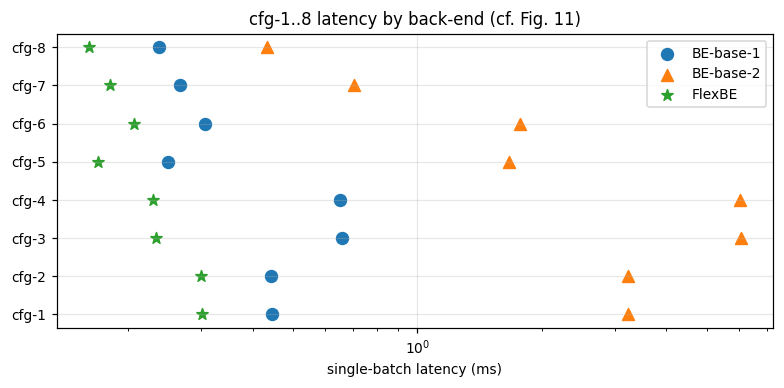

In [12]:
# Pareto view: latency vs the cost model, all eight configs on three back-ends
fig, ax = plt.subplots()
for hwname, mark in [('BE-base-1','o'), ('BE-base-2','^'), ('FlexBE','*')]:
    xs = [bs.latency_ms(c, bs.HW[hwname]) for c in bs.CONFIGS.values()]
    ax.scatter(xs, list(range(1,9)), marker=mark, s=60, label=hwname)
ax.set_yticks(range(1,9)); ax.set_yticklabels(list(bs.CONFIGS))
ax.set_xlabel('single-batch latency (ms)'); ax.set_xscale('log')
ax.set_title('cfg-1..8 latency by back-end (cf. Fig. 11)'); ax.legend()
plt.tight_layout(); plt.show()

---
# Part II — An error in Algorithm 1, and its repair

## 2.1 The two halves of the listing

| lines | content | status |
|---|---|---|
| 5–6 | $ii \leftarrow \mathrm{rotate}_{n-1}(base, k{+}1)$; $I^i[0] \leftarrow \mathrm{rotate}_n(2\,ii, k)$ | **does not give a conflict-free grouping** |
| 7–11 | $R^i = \mathrm{bsm}(I^i[0])$; $S^i = n{-}k{-}1$ on $(n{-}m)..(n{-}2)$, else 0 | correct — keep verbatim |

Rewriting the printed expression exposes the likely origin. Since
$\mathrm{rotate}_n(2x, k) = \mathrm{ins}(\mathrm{rotate}_{n-1}(x,k),k)$ where
$\mathrm{ins}$ inserts a zero bit,

$$I^i[0] = \mathrm{ins}\big(\mathrm{rotate}_{n-1}(base,\,2k+1),\; k\big)$$

— the operand is rotated **twice** by roughly the stage index, and the hole
lands at bit $k$ rather than $n-1-k$. Only $h = n-1-k$ is compatible with line 9
and with the Sec. 3.3 write-back.

In [13]:
def alg1_published(n, P_bu, k, j, rot=1):
    "Algorithm 1 lines 5-6 exactly as printed (rot=1); rot=0 tries the other reading."
    return fx.rotl(2*fx.rotl(j*P_bu, k+rot, n-1), k, n)

# identity check: the printed form equals ins(rotate(base, 2k+1), k)
n_, P_bu = 10, 16
ok = all(alg1_published(n_,P_bu,k,j) ==
         fx.insert_zero(fx.rotl(j*P_bu, 2*k+1, n_-1), k)
         for k in range(n_) for j in range(1 << (n_-5)))
print("rotate_n(2*ii,k) == ins(rotate_{n-1}(base,2k+1), k) :", ok)

rotate_n(2*ii,k) == ins(rotate_{n-1}(base,2k+1), k) : True


## 2.2 Evidence (a): the representatives miss the cycles

For each stage, the $N/(2P_{bu})$ values of $I^i[0]$ should name one cycle each.
Below, both rotation readings and both stage orders are tried; the printed
formula fails at the first stage in every size tested.

In [14]:
rules = {'DIF  h=n-1-k': lambda n,k: n-1-k, 'DIT  h=k    ': lambda n,k: k}
print(f"{'N':>7} {'P_bu':>5} {'stage order':>13} {'rot':>5}  result")
for nn, P_bu in [(3,2),(5,2),(8,4),(10,16),(12,16)]:
    mm = (2*P_bu).bit_length()-1
    if nn < mm: continue
    for label, rule in rules.items():
        for rot in (1,0):
            bad = None
            for k in range(nn):
                h = rule(nn,k)
                groups = list(fx._stage_groups(nn,h,mm))
                gid = np.zeros(1<<nn, int)
                for g,(ix,_,_) in enumerate(groups): gid[ix] = g
                reps = [alg1_published(nn,P_bu,k,j,rot) for j in range(len(groups))]
                if sorted(gid[reps]) != list(range(len(groups))):
                    bad = (k,h); break
            tag = "consistent" if bad is None else f"FAILS at k={bad[0]} (h={bad[1]})"
            print(f"{1<<nn:>7} {P_bu:>5} {label:>13} {'k+'+str(rot):>5}  {tag}")

      N  P_bu   stage order   rot  result
      8     2  DIF  h=n-1-k   k+1  FAILS at k=0 (h=2)
      8     2  DIF  h=n-1-k   k+0  FAILS at k=0 (h=2)
      8     2  DIT  h=k       k+1  FAILS at k=0 (h=0)
      8     2  DIT  h=k       k+0  FAILS at k=2 (h=2)
     32     2  DIF  h=n-1-k   k+1  FAILS at k=0 (h=4)
     32     2  DIF  h=n-1-k   k+0  FAILS at k=0 (h=4)
     32     2  DIT  h=k       k+1  FAILS at k=0 (h=0)
     32     2  DIT  h=k       k+0  FAILS at k=1 (h=1)
    256     4  DIF  h=n-1-k   k+1  FAILS at k=0 (h=7)
    256     4  DIF  h=n-1-k   k+0  FAILS at k=0 (h=7)
    256     4  DIT  h=k       k+1  FAILS at k=0 (h=0)
    256     4  DIT  h=k       k+0  FAILS at k=1 (h=1)
   1024    16  DIF  h=n-1-k   k+1  FAILS at k=0 (h=9)
   1024    16  DIF  h=n-1-k   k+0  FAILS at k=0 (h=9)
   1024    16  DIT  h=k       k+1  FAILS at k=0 (h=0)
   1024    16  DIT  h=k       k+0  FAILS at k=1 (h=1)
   4096    16  DIF  h=n-1-k   k+1  FAILS at k=0 (h=11)
   4096    16  DIF  h=n-1-k   k+0  FAIL

## 2.3 Evidence (b): exhaustive — *no* conflict-free grouping is compatible

Evidence (a) compares against one particular partition, and for some stages more
than one valid partition exists. So for small cases we enumerate **every**
conflict-free grouping of a stage and ask whether any admits the published
$I^i[0]$ values as distinct cycle representatives.

For $N=8$, $P_{bu}=2$ the only conflict-free grouping is the row-based
$\{0,1,2,3\}/\{4,5,6,7\}$, while the formula yields representatives $0$ and $2$ —
which share a row. That is a proof, not a symptom.

In [15]:
import itertools
def matchings(items, size):
    if not items: yield []; return
    first, rest = items[0], items[1:]
    for comb in itertools.combinations(rest, size-1):
        remain = [x for x in rest if x not in comb]
        for tail in matchings(remain, size): yield [(first,)+comb] + tail

for nn, P_bu in [(3,2),(4,2),(5,2)]:
    mm = (2*P_bu).bit_length()-1; N_, Pp = 1<<nn, 1<<mm
    for label, rule in rules.items():
        for rot in (1,0):
            verdict = "feasible"
            for k in range(nn):
                h = rule(nn,k)
                lower = [a for a in range(N_) if not (a>>h)&1]
                parts = [g for g in matchings(lower, P_bu)
                         if all(len({fx.bsm(x,mm) for a in grp for x in (a,a+(1<<h))})==Pp
                                for grp in g)]
                reps = [alg1_published(nn,P_bu,k,j,rot) for j in range(N_//Pp)]
                def cyc_of(part, r):
                    return next(i for i,grp in enumerate(part)
                                if any(r in (a,a+(1<<h)) for a in grp))
                if not any(len({cyc_of(p,r) for r in reps})==len(reps) for p in parts):
                    verdict = (f"INFEASIBLE at k={k} (h={h}): none of {len(parts)} "
                               f"conflict-free partitions admits reps={reps}")
                    break
            print(f"N={N_:>3} P_bu={P_bu} {label} rot=k+{rot}: {verdict}")

N=  8 P_bu=2 DIF  h=n-1-k rot=k+1: INFEASIBLE at k=0 (h=2): none of 1 conflict-free partitions admits reps=[0, 2]
N=  8 P_bu=2 DIF  h=n-1-k rot=k+0: INFEASIBLE at k=0 (h=2): none of 1 conflict-free partitions admits reps=[0, 4]
N=  8 P_bu=2 DIT  h=k     rot=k+1: INFEASIBLE at k=0 (h=0): none of 1 conflict-free partitions admits reps=[0, 2]
N=  8 P_bu=2 DIT  h=k     rot=k+0: INFEASIBLE at k=2 (h=2): none of 1 conflict-free partitions admits reps=[0, 2]
N= 16 P_bu=2 DIF  h=n-1-k rot=k+1: INFEASIBLE at k=0 (h=3): none of 4 conflict-free partitions admits reps=[0, 8, 2, 10]
N= 16 P_bu=2 DIF  h=n-1-k rot=k+0: INFEASIBLE at k=0 (h=3): none of 4 conflict-free partitions admits reps=[0, 4, 8, 12]
N= 16 P_bu=2 DIT  h=k     rot=k+1: feasible
N= 16 P_bu=2 DIT  h=k     rot=k+0: feasible
N= 32 P_bu=2 DIF  h=n-1-k rot=k+1: INFEASIBLE at k=0 (h=4): none of 576 conflict-free partitions admits reps=[0, 8, 16, 24, 2, 10, 18, 26]
N= 32 P_bu=2 DIF  h=n-1-k rot=k+0: INFEASIBLE at k=0 (h=4): none of 576 con

## 2.4 The repair

Only lines 5–6 change. With $\mathrm{ins}(x,p) = ((x \gg p) \ll (p{+}1)) \,|\, (x \bmod 2^p)$:

```
h <- n-1-k
if h < m:  H <- j                      I^i[2t] <- (H << m) + ins(t, h)     S^i <- h
else:      e <- j mod 2
           H <- ins(j >> 1, h-m)       I^i[2t] <- (H << m) + 2t + e        S^i <- 0
both:      I^i[2t+1] <- I^i[2t] + 2^h  R^i <- bsm(I^i[0])
```

Three properties worth noting:

1. $S^i = h$ for $h<m$ **is** the published $S^i = n-k-1$ on $(n-m)\le k\le(n-2)$ — line 9 survives untouched;
2. $R^i = \mathrm{bsm}(I^i[0])$ still holds, and reads off the construction as $\mathrm{popcount}(H) + e$, cheaper than recomputing bsm;
3. the revised listing specifies the **whole** vector $I^i[0..2P_{bu}-1]$, which the published version delegates to "a specific circuit" of [11] — the gap a reimplementer falls into.

Conflict freedom is the two-case argument of §1.2. Cost is unchanged in
character: an $(n{-}m)$-bit counter, one insert-a-zero network at a
stage-constant position (one 2:1 mux per bit, select = thermometer code of
$h-m$, folding into the existing barrel-shifter control), and a popcount the bsm
datapath already computes — still far lighter than BE-base's priority-encoder
reverse lookup, so the Fig. 10 comparison is unaffected.

In [16]:
# verified straight from the formula, with no reference to the schedule
print(f"{'N':>7} {'P_bu':>5}  conflict-free  complete  pairing  lines 7-11")
for nn, P_bu in [(3,1),(4,2),(6,2),(6,4),(9,4),(10,16),(12,16)]:
    mm = (2*P_bu).bit_length()-1
    if nn < mm: continue
    N_, Pp = 1<<nn, 1<<mm
    cf = comp = pair = law = True
    for k in range(nn):
        h, seen = nn-1-k, np.zeros(N_, bool)
        wantS = (nn-k-1) if (nn-mm) <= k <= (nn-2) else 0
        for j in range(N_//Pp):
            c = fx.algorithm1_fixed(nn, P_bu, k, j)
            cf   &= len(np.unique(fx.bsm_array(c.indices, mm))) == Pp
            comp &= not seen[c.indices].any(); seen[c.indices] = True
            pair &= bool(np.all(c.indices[1::2]-c.indices[0::2] == (1<<h)))
            law  &= (c.R == fx.bsm(int(c.indices[0]), mm)) and (c.S == wantS)
        comp &= seen.all()
    print(f"{N_:>7} {P_bu:>5}  {str(cf):>13}  {str(comp):>8}  {str(pair):>7}  {law}")

      N  P_bu  conflict-free  complete  pairing  lines 7-11
      8     1           True      True     True  True
     16     2           True      True     True  True
     64     2           True      True     True  True
     64     4           True      True     True  True
    512     4           True      True     True  True
   1024    16           True      True     True  True
   4096    16           True      True     True  True


In [17]:
# end to end: an engine whose control comes ONLY from the repaired listing
for N_, P_bu in [(256,4),(4096,16)]:
    nn = int(math.log2(N_))
    e2 = fx.FlexBE(P_bu)
    e2._sched[(nn,1)] = fx.ButterflySchedule.from_algorithm1_fixed(nn, P_bu, validate=True)
    xx = rng.normal(size=N_) + 1j*rng.normal(size=N_)
    yy, ss = e2.transform(xx, bitrev=True, datapath='cycle')
    err = np.max(np.abs(yy[0]-np.fft.fft(xx)))/np.max(np.abs(np.fft.fft(xx)))
    print(f"N={N_:5d} P_bu={P_bu:3d}: {ss.butterfly_cycles:6d} butterfly cycles, "
          f"relative error vs numpy.fft = {err:.2e}")
print("\nAlso: algorithm1_fixed reproduces the validated schedule cycle for cycle")
print("(test_flexbe.TestSchedule.test_fixed_algorithm1_reproduces_the_schedule).")

N=  256 P_bu=  4:    256 butterfly cycles, relative error vs numpy.fft = 5.28e-16
N= 4096 P_bu= 16:   1536 butterfly cycles, relative error vs numpy.fft = 6.18e-16

Also: algorithm1_fixed reproduces the validated schedule cycle for cycle
(test_flexbe.TestSchedule.test_fixed_algorithm1_reproduces_the_schedule).


---
# Part III — A RISC-V vector extension proposal

## 3.1 The framing: `vrgather` *is* the FCS

RVV 1.0 offers a general crossbar permute whose cost grows quadratically and
which most implementations run at a few elements per cycle. The paper's whole
argument is that butterfly dataflow never needs a general permute — only a
rotation composed with one of $\log_2 VL$ stride permutations. That argument
transfers directly to an ISA proposal.

Where RVV 1.0 is already fine: `vsmul` + `vxrm` give Q1.15 with round-to-nearest-even
and saturation; `vwmacc` covers 32-bit accumulation; unit-stride loads handle
stages whose stride exceeds VL (case B). The gap is case A — the last
$\log_2 VL$ stages of a long FFT plus *every* stage of the short BL transforms,
which is where BSPNet spends most of its cycles — plus bit reversal, twiddle
bandwidth and per-stage control overhead.

## 3.2 The proposed family

| ext | instructions | replaces / enables |
|---|---|---|
| `Zvrot` | `vrotdn.vx`, `vrotup.vx` | $\mathbf{P}_r$; today 2× `vslide` + merge |
| `Zvshfl` | `vshfl.vi`, `vunshfl.vi` | $\mathbf{P}_s$ — a log-depth network, only $\log_2 VL$ states |
| `Zvcplx` | `vcmul`, `vcmla`, `vcadd` (EGS=2) | removes the interleave/deinterleave permutes |
| `Zvbfly` | `vbfly.vv` (twiddle), `vbfly4.vv` (general 2×2) | the BU — and `vbfly4` *is* the FFT/BL duality in the ISA |
| `Zvbrev` | `vbrevn.vx`, `vlbre`/`vsbre` | Sec. 3.3; precedent in C6000, SHARC, Blackfin |
| `Zvtwid` | `vtwid.vx` | avoids the $N/2\cdot\log N$ twiddle table entirely |

Two structural pieces matter more than the opcodes: an **element-group width**
(precedent: EGS in vector crypto) so permute and butterfly work within $2^s$
sub-blocks — that is Algorithm 2's sub-parallelism — and a small **`vbfcfg` CSR**
holding $\{\log_2 l,\ k,\ EGW\}$ so the loop body is stage-invariant.

## 3.3 One observation that only appears once you build it

**$\mathbf{P}_r$ is not needed in the ISA.** The rotation exists to align data
with the shift-down RAM *banks*; a vector register file has no banks. Only the
subset switch $\mathbf{P}_s$ survives. `Zvrot` remains useful for bit reversal
and for the register-boundary cases, but it is not on the critical path — a
conclusion that falls out of §1.2 and would not be obvious from the paper alone.

## 3.4 The counterargument to have an answer for

Segment loads (`vlseg2e`) already deinterleave complex data at the LSU for free,
and the six-step FFT avoids intra-register permutes entirely by paying for
transposes. A reviewer will ask why not just restructure the algorithm. The
answer is *short* transforms — a transpose cannot be amortised over an 8-point BL
layer — which is why this story is stronger with BSPNet in it than with FFT alone.

---
# Part IV — Microcoded accelerator vs custom vector extension

## 4.1 The controlling constraint

At 64 BUs and 300 MHz the datapath retires **64 butterflies per cycle**. Any
programmable front end must therefore issue ≥64 butterflies per instruction just
to break even. If a stage costs 3–6 vector instructions per chunk, you need
~400 butterflies per instruction to keep the pipe full, i.e.
$VL \approx 768$ complex elements $\Rightarrow VLEN \approx 24$ kbit — 24–48×
typical embedded RVV. Fine-grained programmability is the wrong granularity for
a workload with only ~108 coarse operations per inference.

## 4.2 Method: the traces are real

Options C and D generate their actual instruction streams; `run_program`
implements the semantics of every proposed instruction, so the program is
checked against `numpy.fft` **before** any cycle is counted. Instruction counts
are therefore exact; only per-class rates, issue width and clock are assumed.

In [18]:
print(f"{'l':>6} {'n_seq':>6} {'VL':>5} {'variant':>20} {'instr':>8} {'err vs numpy':>14}")
for l, n_seq, vlen in [(8,4096,16384), (32,1024,16384), (4096,1,4096)]:
    for tag, kw in [('Zvbfly fused', dict(fused_butterfly=True)),
                    ('Zvshfl explicit', dict(fused_butterfly=False)),
                    ('RVV 1.0 vrgather', dict(fused_butterfly=False, has_shuffle=False,
                                              has_vtwid=False, has_complex=False))]:
        mc = im.MachineConfig('t', vlen_bits=vlen, lanes=128, **kw)
        xr = rng.normal(size=(n_seq,l)) + 1j*rng.normal(size=(n_seq,l))
        mem = {'x': xr.reshape(-1).astype(complex).copy()}
        prog = im.gen_transform(l, n_seq, mc)
        im.run_program(prog, mem, mc)
        ref = np.fft.fft(xr, axis=1)[:, np.argsort(fx.bit_rev_array(int(math.log2(l))))]
        err = np.max(np.abs(mem['x'].reshape(n_seq,l)-ref))
        print(f"{l:>6} {n_seq:>6} {mc.VL:>5} {tag:>20} {len(prog):>8,} {err:>14.2e}")

     l  n_seq    VL              variant    instr   err vs numpy
     8   4096   512         Zvbfly fused      323       2.98e-15
     8   4096   512      Zvshfl explicit      707       3.66e-15
     8   4096   512     RVV 1.0 vrgather    1,475       3.56e-15
    32   1024   512         Zvbfly fused      453       9.16e-15
    32   1024   512      Zvshfl explicit    1,093       8.38e-15
    32   1024   512     RVV 1.0 vrgather    2,373       7.94e-15
  4096      1   128         Zvbfly fused      726       1.91e-13
  4096      1   128      Zvshfl explicit    1,334       1.76e-13
  4096      1   128     RVV 1.0 vrgather    2,630       1.72e-13


## 4.3 The memory-pass calculation

For $l > VL$ the transform cannot stay resident. Stages with stride $\ge VL$ pair
*different* registers (no permute needed) but cost one load+store pass each; the
final $\log_2 VL$ stages are all done while a chunk is resident, i.e. one further
pass. Hence

$$\text{passes} = \log_2 l - \log_2 VL + 1$$

For the 32,768-point FFT at $VLEN = 16$ kbit ($VL=512$): $15 - 9 + 1 = 7$ passes
$\times\,32768 \times 2$ element accesses $= 459$k accesses per sequence. This is
what the hardwired engine avoids entirely by working in place in banked RAM, and
it is the single largest reason option C loses.

In [19]:
mc = im.MachineConfig('t', vlen_bits=1024, lanes=32)      # VL = 32
prog = im.gen_transform(4096, 1, mc)
elems = sum(i.elems for i in prog if i.cls in ('load','store') and i.imm.get('mem')=='x')
print(f"VL={mc.VL}, l=4096: measured memory passes = {elems/(2*4096):.0f}, "
      f"closed form = {math.log2(4096)-math.log2(mc.VL)+1:.0f}")

VL=32, l=4096: measured memory passes = 8, closed form = 8


## 4.4 The four options, cfg-6 single-batch inference

All options carry the same 64 radix-2 butterfly lanes. Area for the vector
options counts datapath + permute + VRF + banked scratchpad + core, calibrated
to Table 10 (962 LUT and 10 DSP per BU); the accelerator options start from the
Table 11 BSP-Flex system.

In [20]:
rows = im.compare_options()
print(f"{'option':46s} {'cycles':>10s} {'MHz':>5s} {'ms':>7s} {'x hw':>6s} {'LUT':>8s} "
      f"{'fit':>4s} {'neck':>6s} {'inf/s/kLUT':>10s}")
for r in rows:
    print(f"{r['option'][:46]:46s} {r['cycles']:10,.0f} {r['f_mhz']:5.0f} {r['latency_ms']:7.3f} "
          f"{r['speedup_vs_hardwired']:6.2f} {r['lut']:8,} "
          f"{'yes' if r['fits'] else 'NO':>4s} {r['bottleneck']:>6s} {r['perf_per_klut']:10.2f}")

option                                             cycles   MHz      ms   x hw      LUT  fit   neck inf/s/kLUT
hardwired (paper)                                  64,320   300   0.214   1.00  152,553  yes      -      30.57
A  microcoded command processor                    64,592   300   0.215   1.00  160,553  yes datapath      28.93
B  RoCC custom instruction                         64,524   285   0.226   1.06  172,553  yes datapath      25.60
C  RVV + Zvbfly/Zvshfl/Zvtwid (fused)             238,720   250   0.955   4.45  119,342  yes    lsu       8.78
C+ as C-fused, vtwid on its own pipe              230,824   250   0.923   4.31  119,342  yes    lsu       9.08
C* C+ with 512 B/cycle LSU                        110,974   250   0.444   2.07  137,774  yes    alu      16.35
C' RVV + Zvshfl/Zvtwid, separate permute          338,240   250   1.353   6.31  119,342  yes    lsu       6.19
D  RVV 1.0 (vrgather, no Zvcplx/Zvtwid)         1,277,296   250   5.109  23.83  356,910   NO   perm       0.

### Reading the table

* **A (microcoded) 1.00× and B (RoCC) 1.06×** — the sequencing overhead is real but tiny.
* **C (RVV + custom extensions) 4.45×.** My earlier back-of-envelope said 2.3–3.3×; the measured figure is worse because of the memory passes of §4.3 — the FFT layer alone runs 5.7× slower while the BL layers lose only 2.6×.
* **D (RVV 1.0) 24×, and it does not fit XCZU7EV.** By the paper's own Θ(P²) argument a matched-width `vrgather` needs >8× the permute area of the shuffle network. That is a useful *negative* result for the RISC-V vector community.

In [21]:
cfg = bs.CONFIGS['cfg-6']
acc = dict(bs.cycle_breakdown(cfg, bs.HW['BSP-Flex']))
for key in ('C-fused','C-wide'):
    mcx = im.MACHINES[key]
    tot, items = im.bspnet_cycles_isa(cfg, mcx)
    print(f"\n{mcx.name}")
    print(f"  {'layer':44s} {'accel':>10s} {'vector':>10s} {'ratio':>7s} {'neck':>6s}")
    for name, cyc, neck in items:
        a = acc.get(name, float('nan'))
        print(f"  {name:44s} {a:10,.0f} {cyc:10,.0f} {cyc/a:7.2f} {neck:>6s}")
    print(f"  {'total':44s} {sum(acc.values()):10,.0f} {tot:10,.0f} "
          f"{tot/sum(acc.values()):7.2f}")


C  RVV + Zvbfly/Zvshfl/Zvtwid (fused)
  layer                                             accel     vector   ratio   neck
  CC extraction: 4 x 32768-point FFT               15,360     87,040    5.67    lsu
  8 x feature expansion (len 8, x4)                24,576     90,176    3.67    lsu
  8 x MLP-0-{0,1} (len 32, 1024 rows)              20,480     53,504    2.61    lsu
  8 x MLP-1-{0,1} (len 32, 128 rows)                2,560      6,912    2.70    lsu
  8 x MLP-2-{0,1} (len 32, 16 rows)                   320      1,088    3.40    alu
  total                                            64,320    238,720    3.71

C* C+ with 512 B/cycle LSU
  layer                                             accel     vector   ratio   neck
  CC extraction: 4 x 32768-point FFT               15,360     37,150    2.42    alu
  8 x feature expansion (len 8, x4)                24,576     40,976    1.67    alu
  8 x MLP-0-{0,1} (len 32, 1024 rows)              20,480     28,720    1.40    alu
  8 x MLP-1-{0,1

## 4.5 Where the cycles go: VLEN is not the answer, bandwidth is

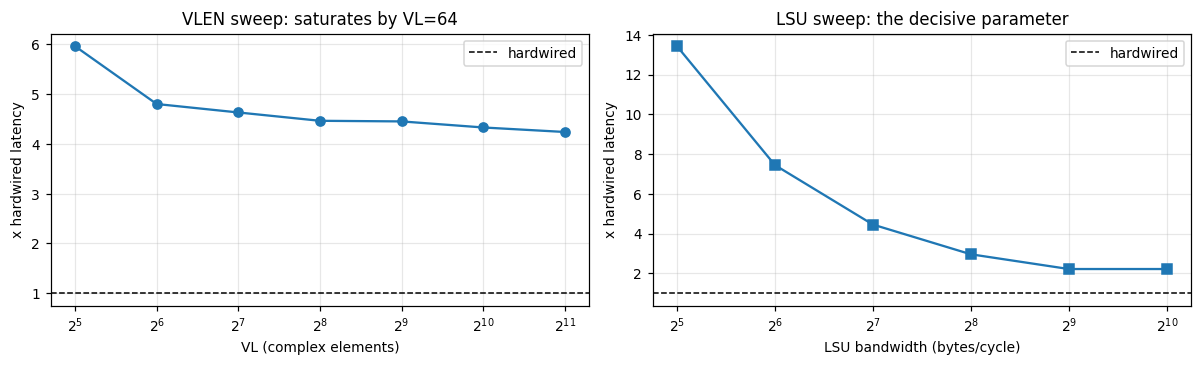

 LSU elem/cyc  B/cycle       ms   x hw   neck
            8       32    2.878  13.42    lsu
           16       64    1.596   7.44    lsu
           32      128    0.955   4.45    lsu
           64      256    0.634   2.96    alu
          128      512    0.475   2.22    alu
          256     1024    0.475   2.22    alu


In [22]:
vs = im.vlen_sweep()
ls = im.lsu_sweep()
hw_ms = bs.latency_ms(cfg, bs.HW['BSP-Flex'])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot([r['VL'] for r in vs], [r['latency_ms']/hw_ms for r in vs], 'o-')
a1.axhline(1.0, ls='--', c='k', lw=1, label='hardwired')
a1.set_xscale('log', base=2); a1.set_xlabel('VL (complex elements)')
a1.set_ylabel('x hardwired latency'); a1.set_title('VLEN sweep: saturates by VL=64'); a1.legend()

a2.plot([r['bytes_per_cycle'] for r in ls], [r['ratio'] for r in ls], 's-')
a2.axhline(1.0, ls='--', c='k', lw=1, label='hardwired')
a2.set_xscale('log', base=2); a2.set_xlabel('LSU bandwidth (bytes/cycle)')
a2.set_ylabel('x hardwired latency'); a2.set_title('LSU sweep: the decisive parameter'); a2.legend()
plt.tight_layout(); plt.show()

print(f"{'LSU elem/cyc':>13} {'B/cycle':>8} {'ms':>8} {'x hw':>6} {'neck':>6}")
for r in ls:
    print(f"{r['lsu']:>13} {r['bytes_per_cycle']:>8} {r['latency_ms']:>8.3f} "
          f"{r['ratio']:>6.2f} {r['bottleneck']:>6}")

### The three findings

1. **The vector options are operand-bandwidth bound, not compute bound.** VLEN saturates by $VL=64$; past that the machine is not short of vector length, it is short of bandwidth. Closing the gap needs ~512 B/cycle — a wide banked on-chip scratchpad beside the lanes, which is **option B with extra steps**. Making C fast *converges on* B rather than competing with it.
2. **Fusing the permute into the butterfly beats adding a permute instruction.** `vbfly.vv` with a stride field — the PRS inside the functional unit, exactly the Fig. 1b arrangement — emits *zero* permute instructions and is 1.4× faster than `vshfl` + butterfly + `vunshfl`.
3. Two second-order effects the model surfaced: `vtwid` must not share the vector ALU issue port (~1.15×), and twiddle vectors are loop-invariant across chunks so the compiler must hoist them (~1.15×).

In [23]:
for key in ('C-fused','C-explicit','D-rvv10'):
    mcx = im.MACHINES[key]
    prog = im.gen_transform(8, 4096, mcx)
    rep  = im.IssueModel(mcx).run(prog)
    mix  = {}
    for i in prog: mix[i.cls] = mix.get(i.cls,0)+1
    print(f"\n{mcx.name}")
    print("  " + "  ".join(f"{c}={mix.get(c,0):>6,}" for c in
                           ['load','store','twid','perm','arith','mul']))
    print(f"  {rep}")


C  RVV + Zvbfly/Zvshfl/Zvtwid (fused)
  load=    64  store=    64  twid=     3  perm=     0  arith=   192  mul=     0
  2,824 cycles, 323 instructions, bottleneck=lsu [alu=28%, lsu=73%]

C' RVV + Zvshfl/Zvtwid, separate permute
  load=    64  store=    64  twid=     3  perm=   384  arith=   192  mul=     0
  4,352 cycles, 707 instructions, bottleneck=lsu [alu=18%, lsu=47%, perm=35%]

D  RVV 1.0 (vrgather, no Zvcplx/Zvtwid)
  load=   451  store=    64  twid=     0  perm=   384  arith=   192  mul=   384
  16,688 cycles, 1,475 instructions, bottleneck=perm [alu=14%, lsu=49%, perm=74%]


## 4.6 Recommendation, and what option B looks like concretely

**B, not A or C.** A is the right performance answer but a weak contribution
("we added a sequencer"). C gives the best story and the worst result — a
reviewer reads it as a 3–4× slower FlexBE with a compiler. B gets ~95% of
hardwired performance with a standard programming model, and has a defensible
novelty claim: *the butterfly memory is architectural state, not a register
file.* That preserves in-place operation, the private coefficient port and the
conflict-free addressing — precisely what a VRF-based ISA destroys.

### Architectural state

| state | size ($P_{be}=4$, $P_{bu}=16$) | notes |
|---|---|---|
| `BSPM` butterfly scratchpad | 256 KB | addressed by **logical element index**; the shift-down skew stays in hardware |
| `CRAM` coefficient RAM | 64 KB (URAM, per Table 11) | twiddles or BL weights, `[2,2,l/2,log2 l]` |
| `bsp.cfg` | 64b CSR | default $l$, $P_{sub}$, $P_N$, rounding, Q-format |
| `bsp.status` | 64b | busy mask, queue depth, error, cycle counter |

### Primitives

```
bs.load   rd, rs1, rs2   mem -> BSPM   (rs2 = {spm_off, count, fmt})
bs.store  rd, rs1, rs2   BSPM -> mem   flags: {natural, BITREV, MAG}
bs.wload  rd, rs1, rs2   mem -> CRAM
bs.bfly   rd, rs1, rs2   P_N transforms of length l
                         rs1 = {spm_src, spm_dst, coeff}
                         rs2 = {log2_l, log2_Psub, P_N, mode, stage_lo, stage_hi}
                         mode: FFT | IFFT | BL | BL_EXPAND
bs.brev   rd, rs1, rs2   standalone Alg. 3 pass
bs.pow    rd, rs1, rs2   elementwise s^2..s^8            (Eq. 1)
bs.mag    rd, rs1, rs2   |x|, optional peak-normalise
bs.pool   rd, rs1, rs2   LayerNorm -> shortcut -> ReLU -> maxpool  (NormPool)
bs.wait / bs.fence / bs.stat
```

Design rules that matter:

* **`BITREV` is a store addressing mode, not an instruction** — Algorithm 3 costs nothing extra when fused into write-back, and disappears for cfg-4.
* **One `bs.bfly` retires Eq. (10) cycles of work** — the equation is literally the instruction's latency formula, and $P_{sub}$/$P_N$ become operand fields rather than CSR pokes.
* **The glue is not optional**: Table 11 shows Magnitude Computation at 41k LUT (26%). Without `bs.pow`/`bs.mag`/`bs.pool` you round-trip through memory and lose the win.
* **Commands are non-blocking** — the queue is what keeps overhead near 1%, giving the Fig. 8 overlap. Without it, DMA serialises against compute and 1.06× becomes ~1.4×.
* **Do not** add `bs.setbank`, `bs.prs`, or anything naming a cycle index. Once a binary knows the bank mapping the schedule is frozen — and Part II is exactly the story of why the schedule may need to change.

**Known hard part**: context switching with architectural scratchpad state
(Hwacha and Gemmini both wrestled with this). Options in increasing effort:
process-private and non-preemptible for the command's duration; a dirty bit with
OS save/restore via `bs.store`/`bs.load`; full shadow state. For an edge RFML box
the first is probably enough — but say so explicitly.

---
# Part V — Attaching it to a Zynq UltraScale+ MPSoC

## 5.1 Option B cannot exist as such on Zynq

The A53 is hard IP: there is no custom-instruction port (Arm Custom Instructions
are Cortex-M33/M55 only, and the A53 is ARMv8.0 — 128-bit NEON, no SVE). So
option B becomes **a PL-side sequencer fed by descriptors**, i.e. option A —
which is fine, since A measured 1.00×. The custom-instruction advantage was
low-latency issue, and Part IV showed the datapath, not issue, is the limit.

Option C is also unavailable: NEON gives $VL=4$ complex elements, ~128× short of
the §4.5 requirement. A vector path here means a soft RVV core in PL, at the LUT
cost measured above.

## 5.2 Port map

| interface | width | use |
|---|---|---|
| `S_AXI_HP0-3_FPD` | 4 × 128b | bulk IQ in / features out (what Fig. 12 uses) |
| `S_AXI_HPC0_FPD` | 128b, coherent via CCI-500 | descriptor fetch, completion |
| `S_AXI_ACP_FPD` | 128b, allocates into A53 L2 | completion words only — **not** bulk data |
| `M_AXI_HPM0_FPD` | 32/128b | control registers, doorbell |
| `M_AXI_HPM0_LPD` | 32b | the same, driven by the R5F |

## 5.3 Why descriptors rather than MMIO — the arithmetic

cfg-6 issues ~104 commands against a 214 µs budget:

$$104 \text{ commands} \times 0.4\,\mu s \text{ (posted MMIO)} = 42\,\mu s = 19\% \text{ overhead}$$

and with PYNQ's per-transfer Python cost it is far worse. A descriptor ring in
coherent memory with one doorbell reduces this to a prefetched fetch that hides
under compute. Better still: **the BSPNet command graph is static** — build the
~104 descriptors once at init, then per inference update one input pointer and
ring the doorbell.

In [24]:
cmds = zm.bspnet_commands(cfg, bs.HW['BSP-Flex'])
kinds = {}
for c in cmds: kinds[c.kind] = kinds.get(c.kind,0)+1
print(f"{len(cmds)} commands per inference:", ", ".join(f"{k}={v}" for k,v in sorted(kinds.items())))
print(f"datapath time: {bs.total_cycles(cfg, bs.HW['BSP-Flex'])/300e6*1e6:.1f} us\n")
for c in cmds[:8]:
    d = f"{c.nbytes/1024:.0f} KB" if c.nbytes else f"{c.cycles:,.0f} cyc"
    print(f"  {c.name:32s} {c.kind:8s} {d:>11s}  deps={list(c.deps)}")

104 commands per inference: compute=102, dma_in=1, dma_out=1
datapath time: 214.4 us

  bs.load  IQ chunk 0              dma_in        128 KB  deps=[]
  bs.pow   S2                      compute      256 cyc  deps=[0]
  bs.pow   S4                      compute      256 cyc  deps=[0]
  bs.pow   S6                      compute      256 cyc  deps=[0]
  bs.pow   S8                      compute      256 cyc  deps=[0]
  bs.bfly  4 x N-point FFT         compute   15,360 cyc  deps=[1, 2, 3, 4]
  bs.store BITREV write-back       compute    1,024 cyc  deps=[5]
  bs.mag   branch 0                compute      256 cyc  deps=[6]


In [25]:
print(f"{'platform':54s} {'us':>8s} {'ovh%':>7s} {'sps':>7s} {'critical':>9s}")
for r in zm.compare_platforms():
    print(f"{r['name'][:54]:54s} {r['latency_us']:8.1f} {r['overhead_pct']:7.1f} "
          f"{r['throughput']:7.0f} {r['critical']:>9s}")

print("\nprefetch depth (static ring, batch 1):")
for r in zm.ring_depth_sweep():
    print(f"  depth {r['depth']:3d}: {r['latency_us']:7.1f} us  +{r['overhead_pct']:5.1f}%  "
          f"critical={r['critical']}")

b = zm.port_budget()
print(f"\nlink budget: in {b['in_bytes']/1024:.0f} KB + out {b['out_bytes']/1024:.1f} KB "
      f"per {b['latency_ms']:.3f} ms")
print(f"  required {b['required_gbs']:.2f} GB/s of {b['available_gbs']:.1f} available "
      f"({b['utilisation']:.0%}); minimum HP ports = {b['min_hp_ports']}")

platform                                                     us    ovh%     sps  critical
PYNQ / Jupyter flow (as measured in the paper)            878.3   281.2    1139      host
MMIO per command, A53 + Linux driver                      258.1    12.0    3874   compute
MMIO per command, A53 bare metal                          252.2     9.4    3966   compute
descriptor ring rebuilt per inference, A53                252.5     9.6    3960   compute
static descriptor ring + doorbell, A53                    252.5     9.6    3961   compute
static ring, Cortex-R5F drives it (RPU)                   252.0     9.4    3968   compute
static ring, per-resource queues, streamed input (R5)     250.3     8.7    3995   compute

prefetch depth (static ring, batch 1):
  depth   1:   255.5 us  + 10.9%  critical=compute
  depth   2:   255.5 us  + 10.9%  critical=compute
  depth   4:   253.1 us  +  9.9%  critical=compute
  depth   8:   252.5 us  +  9.6%  critical=compute
  depth  16:   252.5 us  +  9.6%  cr

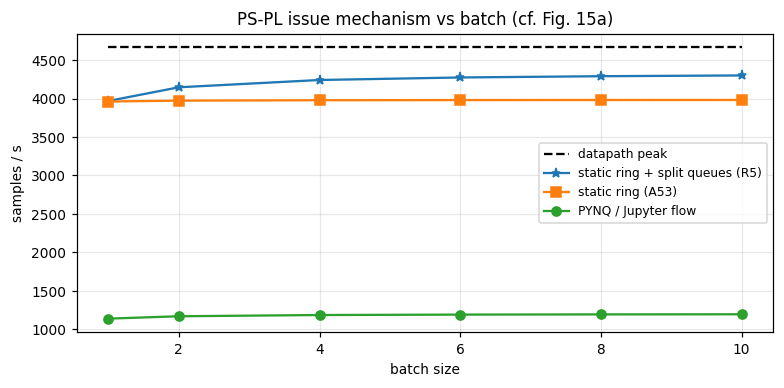

 batch      PYNQ  static ring   tuned R5      peak  tuned/peak
     1      1139         3961       3968      4664        85%
     2      1169         3972       4146      4664        89%
     4      1185         3978       4241      4664        91%
     6      1191         3980       4274      4664        92%
     8      1194         3981       4290      4664        92%
    10      1195         3981       4300      4664        92%


In [26]:
rowsb = zm.batch_sweep(keys=('pynq','static-a53','tuned-r5'))
fig, ax = plt.subplots()
bx = [r['batch'] for r in rowsb]
ax.plot(bx, [r['peak'] for r in rowsb], 'k--', label='datapath peak')
ax.plot(bx, [r['tuned-r5'] for r in rowsb], '*-', label='static ring + split queues (R5)')
ax.plot(bx, [r['static-a53'] for r in rowsb], 's-', label='static ring (A53)')
ax.plot(bx, [r['pynq'] for r in rowsb], 'o-', label='PYNQ / Jupyter flow')
ax.set_xlabel('batch size'); ax.set_ylabel('samples / s')
ax.set_title('PS-PL issue mechanism vs batch (cf. Fig. 15a)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'batch':>6} {'PYNQ':>9} {'static ring':>12} {'tuned R5':>10} {'peak':>9} {'tuned/peak':>11}")
for r in rowsb:
    print(f"{r['batch']:>6} {r['pynq']:>9.0f} {r['static-a53']:>12.0f} {r['tuned-r5']:>10.0f} "
          f"{r['peak']:>9.0f} {r['tuned-r5']/r['peak']:>10.0%}")

### What the Zynq model says

* **The PYNQ flow is host bound (+281%), not accelerator bound.** ~104 commands × (Python call + posted MMIO + polled completion) swamps a 214 µs inference. Much of the gap between the solid and dashed lines of Fig. 15a is PS-side software, and a descriptor ring recovers it **without touching the PL**.
* **Prefetch saturates at 4–8 descriptors.** Deeper buys nothing at batch 1.
* **Per-resource queues matter only across inferences.** With one shared ring the next sample's input-DMA descriptor sits behind ~100 compute descriptors and cannot start early; splitting the ring takes batch-10 throughput from 3,981 to 4,300 samples/s — **92% of datapath peak**. Cheap change, invisible in a bandwidth analysis.
* **The link is never the constraint**: 0.62 GB/s of 6.4 available, so **one HP port suffices**. The four ports buy burst overlap for a single record, not throughput.
* The residual ~9% at batch 1 is the 128 KB input transfer, which overlaps nothing unless the accelerator ingests from a live AXI-stream SDR front end — an option Fig. 12 already shows, and the strongest single change for a batch-1 claim.

### Practical notes

* Use the **Cortex-R5F in the RPU** as the "option B core": on-die, 500–600 MHz, TCM, deterministic low-latency PL access via `M_AXI_HPM0_LPD`, leaving the A53 for Linux/PYNQ. Split with OpenAMP/rpmsg.
* `pynq.allocate()` gives uncached buffers — right for bulk IQ over HP, wrong for descriptors and completion words, which want cacheable memory through HPC/ACP with explicit flush/invalidate.
* **Do not use PL–PS interrupts for 214 µs jobs**: Linux IRQ latency is 5–10 µs. Write a completion word through ACP and poll it.

---
# Part VI — Consolidated results, assumptions, and what to measure next

## 6.1 Everything in one table

In [27]:
peak_ms = bs.latency_ms(cfg, bs.HW['BSP-Flex'])
print(f"cfg-6 single-batch reference: {bs.total_cycles(cfg, bs.HW['BSP-Flex']):,.0f} cycles "
      f"= {peak_ms:.3f} ms at 300 MHz\n")
print(f"{'implementation route':52s} {'ms':>8s} {'x hw':>6s} {'note':>28s}")
for r in im.compare_options():
    note = {'none':'fixed function','descriptors':'command graph at runtime',
            'C':'full C / compiler','RVV toolchain':'full RVV toolchain'}.get(r['programmability'],'')
    print(f"{r['option'][:52]:52s} {r['latency_ms']:8.3f} {r['speedup_vs_hardwired']:6.2f} {note:>28s}")
print()
for r in zm.compare_platforms():
    print(f"{('Zynq: '+r['name'])[:52]:52s} {r['latency_us']/1e3:8.3f} "
          f"{r['latency_us']/1e3/peak_ms:6.2f} {('bound by '+r['critical']):>28s}")

cfg-6 single-batch reference: 64,320 cycles = 0.214 ms at 300 MHz

implementation route                                       ms   x hw                         note
hardwired (paper)                                       0.214   1.00               fixed function
A  microcoded command processor                         0.215   1.00     command graph at runtime
B  RoCC custom instruction                              0.226   1.06            full C / compiler
C  RVV + Zvbfly/Zvshfl/Zvtwid (fused)                   0.955   4.45           full RVV toolchain
C+ as C-fused, vtwid on its own pipe                    0.923   4.31           full RVV toolchain
C* C+ with 512 B/cycle LSU                              0.444   2.07           full RVV toolchain
C' RVV + Zvshfl/Zvtwid, separate permute                1.353   6.31           full RVV toolchain
D  RVV 1.0 (vrgather, no Zvcplx/Zvtwid)                 5.109  23.83           full RVV toolchain

Zynq: PYNQ / Jupyter flow (as measured in the pape

## 6.2 What is measured vs what is assumed

**Measured** (executed code, exact by construction):

* every cycle of the FlexBE schedule — bank conflicts, coverage, PRS/FCS equivalence, arithmetic;
* FFT/BL numerical results against `numpy.fft`;
* Algorithm 3's permutation, conflict freedom and $N/P$ cycle count;
* instruction *counts* for options C and D — the traces are generated and functionally executed;
* command counts and dependency structure for the Zynq stream.

**Assumed** (all in named dataclasses, one line to change):

| assumption | value | confidence |
|---|---|---|
| vector clock (`MachineConfig.f_mhz`) | 250 MHz | soft — a multi-ported VRF is a harder timing problem than the PRS pipeline |
| VRF read/write bandwidth | 384 / 128 elem/cyc | medium |
| `vrgather` rate | 16 elem/cyc | medium; implementation-defined in RVV |
| LUT/DSP per BU | 962 / 10 | **hard** — calibrated to Table 10 |
| posted MMIO write | 0.40 µs | medium |
| PYNQ per-transfer cost | 25 µs | soft — but the qualitative conclusion is robust to 5–50 µs |
| Linux IRQ latency | 6 µs | medium |
| DDR sustained bandwidth | 6.4 GB/s | conservative; irrelevant, utilisation is 10% |

Two modelling choices worth flagging in any write-up: the Zynq command stream adds
`bs.pow`/`bs.mag`/`bs.pool` as separate commands (~16 µs, +7% over 214 µs) which
the RTL may fuse; and option C's area excludes AXI/DMA infrastructure that
Table 11 includes for the accelerator.

## 6.3 The experiment that would settle it

Build option B on the same ZCU104, reusing the existing Verilog BE array
untouched, and measure three points — hardwired (Table 11), B, and a cut-down C
(8–16 butterflies/cycle, whatever fits) — reporting **performance per LUT** and
**cycles per butterfly**. Two results make it publishable:

1. B costs <10% against hardwired — programmability is nearly free at this granularity;
2. the crossbar-area argument shows the naive RVV point is *off the device* — a genuinely useful negative result for the RISC-V vector community, and the same Θ(P²) vs Θ(mP) argument the paper already owns.

Add the descriptor-ring measurement from Part V and you also close most of the
Fig. 15a solid-vs-dashed gap, which strengthens the existing single-batch claim
at essentially no hardware cost.

## 6.4 Recommended paper actions

1. **Fix Algorithm 1 lines 5–6** (Part II); `docs/algorithm1_fixed.tex` is drop-in. Also state the whole vector $I^i$, not just $I^i[0]$.
2. **Clarify Eq. (10)**: $P_N$ = number of length-$l$ sequences, $N$ = engine computational length.
3. **State the row-rotation reading of Eq. (3)** — "row $H$ is rotated by popcount($H$)" makes the conflict-freedom argument a two-liner.
4. Consider noting that the Fig. 15a gap is partly PS-side, with the descriptor-ring number as evidence.

---
# Appendix A — Source code reference

## A.1 `flexbe.py` — the engine

| symbol | role |
|---|---|
| `popcount`, `bit_rev`, `bit_rev_array`, `rotl`, `insert_zero` | bit primitives |
| `bsm`, `bsm_array` | Eq. (3) bank index |
| `FixedPointFormat` | Q1.15, 32-bit accumulate, convergent rounding, saturation |
| `BankedMemory` | $P$ single-port banks; raises `BankConflictError` |
| `PermuteRotateSwitch` | PRS: `read_map`, `forward`, `inverse`, `mux_count` |
| `FullyConnectedSwitch` | FCS reference crossbar + Eq. (4) cost |
| `interconnect_cost` | the Fig. 9 model |
| `CycleControl` | one cycle: $I^i$, Addr$^i$, $R^i$, $S^i$, coefficient addresses |
| `ButterflySchedule` | the whole control sequence; `validate()`, `paper_subset_state()`, `from_algorithm1_fixed()` |
| `algorithm1_fixed` | **the repaired listing**, closed form |
| `fft_coefficients`, `random_bl_coefficients`, `expand_coefficients`, `coefficients_from_paper_layout` | twiddles / BL weights, $P_{sub}$ expansion, Table 4 layout |
| `butterfly_reference` | golden datapath (no memory, no switching) |
| `bitrev_schedule` | Algorithm 3 |
| `FlexBE` | the engine: `transform(x, coeffs, bitrev, stage_scale, datapath)` |
| `BEArray` | $P_{be}$ engines; latency = slowest |
| `cycles_eq10`, `layer_cycles`, `bitrev_cycles` | Eq. (10) and friends |

## A.2 `bspnet.py` — the application

`BSPNetConfig` (Table 7) · `CONFIGS` cfg-1..8 · `HWConfig`/`HW` (BE-base-1,
BE-base-2, FlexBE, BSP-Flex with Table 10 $F_{max}$) · `cycle_breakdown`,
`total_cycles`, `latency_ms`, `throughput_sps` · `BSPNet` with `features` (Eq. 1),
`branch`, `forward` · `design_space_table`.

## A.3 `isa_model.py` — the instruction-level backend

`MachineConfig` (VLEN, lanes, rates, ports, `fused_butterfly`, `has_shuffle`,
`has_vtwid`, `separate_twid_unit`, `hoist_twiddles`) · `Inst`/`Program`/`RegAlloc`/`TwiddlePool` ·
`gen_transform` (the two regimes of §4.3) · `run_program` (functional semantics) ·
`IssueModel` → `CycleReport` · `estimate_area` (calibrated to Table 10) ·
`SEQUENCERS`/`accelerator_cycles` (options A, B) · `compare_options`, `vlen_sweep`, `lsu_sweep`.

## A.4 `zynq_model.py` — PS–PL attachment

`PSPLConfig`/`PLATFORMS` (pynq, mmio-linux, mmio-baremetal, ring-a53, static-a53,
static-r5, tuned-r5) · `Command`/`bspnet_commands` · `PSPLModel` → `RunReport` ·
`compare_platforms`, `ring_depth_sweep`, `batch_sweep`, `port_budget`.

## A.5 Other files

`demo_flexbe.py`, `demo_isa.py`, `demo_zynq.py` — report scripts.
`check_algorithm1.py` — the Part II diagnosis, standalone.
`docs/algorithm1_fix.md`, `docs/algorithm1_fixed.tex` — the repair write-up and a
drop-in `algorithm2e` listing.

---
# Appendix B — The test suite

59 tests. They assert the architectural claims, not just the numerics.

In [28]:
r = subprocess.run([sys.executable, '-m', 'unittest', 'test_flexbe', '-v'],
                   capture_output=True, text=True)
lines = [l for l in r.stderr.splitlines() if ' ... ' in l or l.startswith('Ran ') or l.strip() in ('OK','FAILED')]
groups = {}
for l in lines:
    if ' ... ' in l and '(' in l:
        cls = l.split('(')[1].split('.')[1] if '.' in l.split('(')[1] else '?'
        groups.setdefault(cls, []).append(l.split(' ')[0])
for cls, tests in groups.items():
    print(f"{cls} ({len(tests)})")
    for t in tests: print(f"    {t}")
print()
print("\n".join(l for l in lines if l.startswith('Ran ') or l.strip() in ('OK','FAILED')))

? (6)
    R^i
    A^gb_y[a]
    Short
    log2(l)
    S^i
    Sec.
TestBSPNet (5)
    test_cfg6_latency_is_plausible
    test_feature_extraction_matches_numpy
    test_fft_dominates_only_for_large_din
    test_flexbe_beats_be_base_on_every_config
    test_forward_shape_and_determinism
TestBitHelpers (3)
    test_bit_rev
    test_bsm_matches_vector_version
    test_rotl
  (3)
    Every
    [2,
    Sec.
TestBitReversal (2)
    test_algorithm3_is_a_conflict_free_permutation
    test_bitrev_cycle_count
TestButterflyLinear (2)
    test_bl_matches_dense_matrix
    test_bl_matches_reference_model
TestFFT (3)
    test_cycle_and_vector_datapaths_agree
    test_fft_matches_numpy
    test_inverse_transform
 3 (1)
    P_N
TestFixedPoint (2)
    test_fxp16_fft_accuracy
    test_quantiser
TestISAModel (5)
    test_accelerator_options_stay_close_to_hardwired
    test_fused_butterfly_removes_the_permutes
    test_lsu_sweep_is_monotone_and_saturates
    test_twiddle_hoisting_is_semantics_preserving
   

---
## How to run

```bash
python test_flexbe.py        # 59 tests, ~3 s
python demo_flexbe.py        # engine report;  --full for the real 4 x 32768 FFT
python demo_isa.py           # microcoded vs vector extension
python demo_zynq.py          # PS-PL attachment
python check_algorithm1.py   # the Algorithm 1 diagnosis and the fix
```

Pure NumPy; matplotlib only for this notebook's figures.